# PGNN v13 — Gated Hybrid (Physics Expert + Data Expert) — Al 6011-O Flow Stress

**What's new vs v12:**
1. `GatedHybridPGNN`: sigma = g(x)*sigma_Arrhenius + (1-g(x))*sigma_free — a learned gate decides *where physics is trusted*. Fixes the structural DSA blind spot at RT/150 C (the pure Arrhenius layer is forced to predict positive strain-rate sensitivity everywhere; the free branch is not).
2. `L_gate` prior (fixed lambda, **no uncertainty weighting anywhere** — the v11/v12 analysis showed uncertainty weighting is a confound): pushes g->1 where T>=250 C. Physics loss is finally **non-redundant** because the free branch *could* violate physics.
3. Pure-ANN baseline (`FreeNet`) inside the same LOCO/LOTO harness — fair 3-way story: ANN vs PGNN vs Hybrid.
4. Gate-map figure: g over (T, strain-rate) — the model *learns the validity boundary of the Arrhenius law*. Headline figure.
5. Optional lnZ representation study: feature ln Z = ln(sr) + Q0/(R*T). Q0 = **156.8 kJ/mol measured from THIS dataset** (per-strain sinh-Arrhenius fits, eps 0.05-0.19, R2~0.99 — matches SCAM 157.4). In lnZ mode Q0 is **re-fitted per fold on TRAIN data only** -> no leakage.


## 1 · Imports & Configuration

In [1]:
from __future__ import annotations
import copy, math, os, random, time, warnings, itertools
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings("ignore")
R_GAS = 8.314  # J/(mol K)

@dataclass
class Config:
    # --- paths ---
    data_path: str = "/kaggle/input"   # auto-searches for al6011_downsampled_full.xlsx
    output_dir: str = "."
    # --- data ---
    feature_cols: List[str] = field(default_factory=lambda: ["T_K", "ln_sr", "eps_true"])
    target_col: str = "sigma_true"
    val_ratio: float = 0.15
    # --- model ---
    hidden_dims: List[int] = field(default_factory=lambda: [128, 128, 64])
    dropout: float = 0.1
    # --- hybrid (v13) ---
    free_hidden_dims: List[int] = field(default_factory=lambda: [64, 64])
    gate_hidden: int = 16
    gate_bias_init: float = 2.0      # sigmoid(2) ~ 0.88 -> start physics-dominant
    lambda_gate: float = 0.1         # fixed weight of the gate prior (NO uncertainty weighting: v11/v12 showed it is a confound)
    hot_T_min_K: float = 523.15      # T>=250C = regime where the gate prior trusts physics
    # --- representation (optional lnZ feature; see Section 6) ---
    Q0_J: float = 156_800.0          # fallback; measured from THIS dataset (per-strain sinh-Arrhenius, eps 0.05-0.19)
    # --- training ---
    batch_size: int = 64
    epochs: int = 500
    patience: int = 60
    lr: float = 1e-3
    weight_decay: float = 1e-5
    scheduler_factor: float = 0.5
    scheduler_patience: int = 30
    grad_clip: float = 10.0
    # --- physics (legacy terms kept for compatibility) ---
    scam_temp_min_K: float = 523.0
    scam_eps_min: float = 0.05
    scam_eps_max: float = 0.19
    mono_srate_hot_only: bool = True
    smooth_eps_grid: Tuple[float,float,int] = (0.05, 0.65, 60)
    # --- experiment control ---
    seed: int = 42
    seeds: List[int] = field(default_factory=lambda: [42, 1, 2, 3, 4, 5, 6, 7])
    quick: bool = False   # True = smoke run. Set False for the full study.
    @property
    def device(self): return torch.device("cuda" if torch.cuda.is_available() else "cpu")

CFG = Config()
if CFG.quick:
    CFG.epochs = 60
print("Device:", CFG.device, "| epochs:", CFG.epochs, "| quick:", CFG.quick, "| seeds:", CFG.seeds)


Device: cuda | epochs: 500 | quick: False | seeds: [42, 1, 2, 3, 4, 5, 6, 7]


## 2 · Reproducibility

In [2]:
def seed_everything(seed: int = None) -> None:
    seed = CFG.seed if seed is None else seed
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

## 3 · Data Loading

In [3]:
def _find_data_path(p: str, fname: str = "al6011_downsampled_full.xlsx") -> str:
    """Locate the data file whether `p` is the file itself, a directory, or wrong.
    Preference: exact file -> exact filename anywhere -> *downsampled*.xlsx -> any .xlsx."""
    if os.path.isfile(p):
        return p
    roots = ([p] if os.path.isdir(p) else []) + ["/kaggle/input", "."]
    cands = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dp, _, fns in os.walk(root):
            for fn in fns:
                if fn.lower().endswith((".xlsx", ".xls")):
                    cands.append(os.path.join(dp, fn))
    if not cands:
        raise FileNotFoundError(f"No .xlsx found at/near {p} or /kaggle/input")
    for c in cands:
        if os.path.basename(c) == fname:
            return c
    for c in cands:
        if "downsampled" in os.path.basename(c).lower():
            return c
    return cands[0]

CFG.data_path = _find_data_path(CFG.data_path)
print("Using data file:", CFG.data_path)
xf = pd.ExcelFile(CFG.data_path)
sheets = [s for s in xf.sheet_names if s != "Summary"]
data = pd.concat([pd.read_excel(CFG.data_path, sheet_name=s).assign(condition=s) for s in sheets],
                 ignore_index=True)
print(f"Loaded {len(data):,} points | {data['condition'].nunique()} conditions")

X_all   = data[CFG.feature_cols].values.astype(np.float32)
y_all   = data[CFG.target_col].values.astype(np.float32).reshape(-1, 1)
T_K_raw = data["T_K"].values.astype(np.float32)
sr_raw  = data["strain_rate"].values.astype(np.float32)
eps_raw = data["eps_true"].values.astype(np.float32)
cond_arr= data["condition"].values
ALL_CONDS = list(data["condition"].unique())

Using data file: /kaggle/input/datasets/jpcnvn/downsampled-data/al6011_downsampled_full.xlsx
Loaded 1,982 points | 21 conditions


## 4 · Splits — Random (reference) and Leave-One-Condition-Out (honest)

`random_split` reproduces the original within-condition shuffle (interpolation — optimistic).
`loco_split` holds out one entire condition (extrapolation — the metric that actually tests generalization).
A held-out *temperature* or *strain-rate* variant is also provided for harder extrapolation.

In [4]:
def random_split(seed=CFG.seed, train_ratio=0.70, val_ratio=CFG.val_ratio):
    rng = np.random.default_rng(seed)
    tr, va, te = [], [], []
    for c in ALL_CONDS:
        idx = np.where(cond_arr == c)[0].copy(); rng.shuffle(idx)
        n = len(idx); ntr = int(train_ratio*n); nva = int(val_ratio*n)
        tr += list(idx[:ntr]); va += list(idx[ntr:ntr+nva]); te += list(idx[ntr+nva:])
    return np.array(tr), np.array(va), np.array(te)

def loco_split(holdout_condition, seed=CFG.seed, val_ratio=CFG.val_ratio):
    rng = np.random.default_rng(seed)
    te = np.where(cond_arr == holdout_condition)[0]
    pool = np.where(cond_arr != holdout_condition)[0].copy(); rng.shuffle(pool)
    nva = int(val_ratio*len(pool))
    return pool[nva:], pool[:nva], te

def loto_split(holdout_T_C, seed=CFG.seed, val_ratio=CFG.val_ratio):
    """Leave-one-temperature-out (harder)."""
    rng = np.random.default_rng(seed)
    te = np.where(data["T_C"].values == holdout_T_C)[0]
    pool = np.where(data["T_C"].values != holdout_T_C)[0].copy(); rng.shuffle(pool)
    nva = int(val_ratio*len(pool))
    return pool[nva:], pool[:nva], te

## 5 · SCAM Polynomial (parameter validation + optional legacy term)

SCAM is **not** used as the main physics target (redundant). It is kept to (a) reproduce the legacy
`L_scam` term for the ablation comparison and (b) validate learned parameters against a classical fit.
Coefficients below are the user's fitted polynomials; they are physically sane inside ε∈[0.05,0.19].

In [5]:
SCAM_POLY_COEFFS = {
 "alpha": np.array([ 2.990838465670e+04,-1.994069281431e+04, 5.345762450621e+03,-7.350303313298e+02,
                     5.448368675032e+01,-2.063309588944e+00, 5.051186723984e-02]),
 "n":     np.array([-7.812215710077e+05, 2.343228580944e+05, 4.087839767037e+04,-2.591299218747e+04,
                     4.249708974788e+03,-3.168428320818e+02, 1.508120816407e+01]),
 "Q":     np.array([-8.543584880384e+10, 5.238248618259e+10,-1.249643528684e+10, 1.436699072794e+09,
                    -7.644242300049e+07, 1.055736379502e+06, 1.900591723054e+05]),
 "lnA":   np.array([-2.689844217277e+07, 1.687345535442e+07,-4.163261535534e+06, 5.066408364188e+05,
                    -3.055325125124e+04, 7.305787733034e+02, 2.523144522408e+01]),
}
def scam_sigma_np(eps, T_K, sr):
    a=np.polyval(SCAM_POLY_COEFFS["alpha"],eps); n=np.polyval(SCAM_POLY_COEFFS["n"],eps)
    Q=np.polyval(SCAM_POLY_COEFFS["Q"],eps);     lnA=np.polyval(SCAM_POLY_COEFFS["lnA"],eps)
    Z = sr*np.exp(Q/(R_GAS*T_K))
    return (1.0/a)*np.arcsinh((Z/np.exp(lnA))**(1.0/n))

# precompute SCAM target + validity mask once (used only if 'scam' term is active)
_scam_raw = scam_sigma_np(eps_raw, T_K_raw, sr_raw).astype(np.float64)
SCAM_VALID = (np.isfinite(_scam_raw) & (T_K_raw >= CFG.scam_temp_min_K)
              & (eps_raw >= CFG.scam_eps_min) & (eps_raw <= CFG.scam_eps_max))
_scam_raw[~SCAM_VALID] = 0.0
SCAM_SIGMA = np.clip(_scam_raw, 0, 500).astype(np.float32).reshape(-1,1)
print(f"SCAM valid points: {SCAM_VALID.sum()}/{len(SCAM_VALID)} ({100*SCAM_VALID.mean():.1f}%)")

SCAM valid points: 435/1982 (21.9%)


## 6 · Per-fold Data Prep (scalers fit on train only — no leakage)

`feature_mode="base"` -> (T_K, ln_sr, eps) exactly as v12. `feature_mode="lnZ"` -> adds ln Z = ln(sr) + Q0/(R*T) as a 4th feature, where **Q0 is re-fitted on that fold's TRAINING points only** (per-strain sinh-Arrhenius regression) so LOCO/LOTO stay leakage-free.


In [6]:
def fit_Q0_train(tr_idx) -> float:
    """Classical per-strain sinh-Arrhenius fit on TRAIN rows only (hot regime, valid eps window).
    ln(sr) = lnA + n*ln(sinh(alpha*sigma)) - (Q/R)*(1/T). Returns mean Q over strain levels [J/mol]."""
    df = data.iloc[np.asarray(tr_idx)]
    hot = df[df["T_K"] >= CFG.hot_T_min_K]
    Qs = []
    for eps0 in np.arange(0.05, 0.20, 0.02):
        rows = []
        for _, g in hot.groupby("condition"):
            g = g.sort_values("eps_true")
            if len(g) < 4 or g["eps_true"].min() > eps0 or g["eps_true"].max() < eps0:
                continue
            rows.append((g["T_K"].iloc[0], g["strain_rate"].iloc[0],
                         float(np.interp(eps0, g["eps_true"], g["sigma_true"]))))
        if len(rows) < 10:
            continue
        T, sr, sig = map(np.array, zip(*rows))
        best = None
        for a in np.arange(0.010, 0.041, 0.005):
            X = np.column_stack([np.log(np.sinh(a*sig)), 1.0/T, np.ones_like(T)])
            yv = np.log(sr)
            beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
            r2 = 1 - ((yv - X@beta)**2).sum() / ((yv - yv.mean())**2).sum()
            if best is None or r2 > best[0]:
                best = (r2, -beta[1]*R_GAS)
        Qs.append(best[1])
    return float(np.mean(Qs)) if Qs else CFG.Q0_J

def _featurize(T_K, ln_sr, eps, mode="base", Q0=None):
    base = np.stack([T_K, ln_sr, eps], 1).astype(np.float32)
    if mode == "base":
        return base
    lnZ = (ln_sr + (Q0 or CFG.Q0_J)/(R_GAS*T_K)).astype(np.float32).reshape(-1, 1)
    return np.concatenate([base, lnZ], 1)

@dataclass
class Fold:
    tr: np.ndarray; va: np.ndarray; te: np.ndarray
    sx: StandardScaler; sy: StandardScaler
    smooth_grid: torch.Tensor
    device: torch.device
    X: np.ndarray            # feature matrix for THIS fold (depends on feature_mode)
    Q0: Optional[float]
    feature_mode: str

def prep_fold(tr, va, te, feature_mode="base") -> Fold:
    Q0 = fit_Q0_train(tr) if feature_mode != "base" else None
    X = _featurize(T_K_raw, np.log(sr_raw), eps_raw, feature_mode, Q0)
    sx = StandardScaler().fit(X[tr]); sy = StandardScaler().fit(y_all[tr])
    lo, hi, g = CFG.smooth_eps_grid
    eg = np.linspace(lo, hi, g).astype(np.float32)
    grid_raw = _featurize(np.full_like(eg, 723.15), np.full_like(eg, np.log(0.01)), eg,
                          feature_mode, Q0)
    grid = torch.tensor(sx.transform(grid_raw).astype(np.float32), device=CFG.device)
    return Fold(tr, va, te, sx, sy, grid, CFG.device, X, Q0, feature_mode)

def make_loader(F: Fold, idx, shuffle):
    t = (torch.tensor(F.sx.transform(F.X[idx]).astype(np.float32)),
         torch.tensor(((y_all[idx]-F.sy.mean_[0])/F.sy.scale_[0]).astype(np.float32)),
         torch.tensor(T_K_raw[idx].reshape(-1,1)), torch.tensor(sr_raw[idx].reshape(-1,1)),
         torch.tensor(eps_raw[idx].reshape(-1,1)),
         torch.tensor(((SCAM_SIGMA[idx]-F.sy.mean_[0])/F.sy.scale_[0]).astype(np.float32)),
         torch.tensor(SCAM_VALID[idx].astype(np.float32).reshape(-1,1)))
    bs = CFG.batch_size if shuffle else 256
    return DataLoader(TensorDataset(*t), batch_size=bs, shuffle=shuffle)


## 7 · Models — HybridPGNN (physics expert), FreeNet (data expert), GatedHybridPGNN (mixture)

The gate g(x) in [0,1] blends the two experts: **sigma = g*sigma_phys + (1-g)*sigma_free**. Initialized physics-dominant (g~0.88). The free branch CAN represent negative strain-rate sensitivity (DSA at RT/150) — the Arrhenius branch cannot. So the gate has a real decision to make, and the gate prior (Section 8) is a physics loss that is finally non-redundant.


In [7]:
PARAM_BOUNDS = {"alpha": (0.005, 0.045), "n": (2.0, 8.0), "Q": (130_000, 90_000), "lnA": (15.0, 25.0)}

class HybridPGNN(nn.Module):
    """Physics expert: NN -> (alpha, n, Q, lnA) -> sinh-Arrhenius -> sigma. Unchanged from v12."""
    def __init__(self, input_dim=3, hidden_dims=None, dropout=CFG.dropout):
        super().__init__()
        hidden_dims = hidden_dims or CFG.hidden_dims
        layers, d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        self.backbone = nn.Sequential(*layers)
        self.heads = nn.ModuleDict({k: nn.Linear(hidden_dims[-1], 1) for k in PARAM_BOUNDS})

    def raw_params(self, x_scaled):
        h = self.backbone(x_scaled)
        return {k: torch.sigmoid(self.heads[k](h)) for k in PARAM_BOUNDS}

    def forward(self, x_scaled, T_K, sr, eps):
        h = self.backbone(x_scaled)
        p = {k: lo + rng_*torch.sigmoid(self.heads[k](h)) for k,(lo,rng_) in PARAM_BOUNDS.items()}
        Z   = sr*torch.exp(torch.clamp(p["Q"]/(R_GAS*T_K), max=80.0))
        rat = torch.clamp(Z/torch.exp(p["lnA"]), min=1e-10, max=1e30)
        sigma = (1.0/p["alpha"])*torch.arcsinh(rat**(1.0/p["n"]))
        return sigma, p

class FreeNet(nn.Module):
    """Data expert: plain MLP -> sigma (in target-scaled units, un-scaled at output).
    Unconstrained: CAN model DSA / negative strain-rate sensitivity."""
    def __init__(self, input_dim=3, hidden_dims=None, dropout=CFG.dropout):
        super().__init__()
        hidden_dims = hidden_dims or CFG.free_hidden_dims
        layers, d = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(dropout)]; d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
        self.y_mean, self.y_scale = 0.0, 1.0

    def set_output_scale(self, mean, scale):
        self.y_mean, self.y_scale = float(mean), float(scale)

    def forward(self, x_scaled, T_K=None, sr=None, eps=None):
        z = self.net(x_scaled)
        return z*self.y_scale + self.y_mean, {}

class GatedHybridPGNN(nn.Module):
    """sigma = g(x)*sigma_phys + (1-g(x))*sigma_free. Gate init physics-dominant."""
    def __init__(self, input_dim=3):
        super().__init__()
        self.phys = HybridPGNN(input_dim=input_dim)
        self.free = FreeNet(input_dim=input_dim)
        self.gate = nn.Sequential(nn.Linear(input_dim, CFG.gate_hidden), nn.Tanh(),
                                  nn.Linear(CFG.gate_hidden, 1))
        with torch.no_grad():
            self.gate[-1].bias.fill_(CFG.gate_bias_init)

    def set_output_scale(self, mean, scale):
        self.free.set_output_scale(mean, scale)

    def raw_params(self, x_scaled):          # passthrough for legacy losses
        return self.phys.raw_params(x_scaled)

    def gate_value(self, x_scaled):
        return torch.sigmoid(self.gate(x_scaled))

    def forward(self, x_scaled, T_K, sr, eps):
        s_p, p = self.phys(x_scaled, T_K, sr, eps)
        s_f, _ = self.free(x_scaled)
        g = self.gate_value(x_scaled)
        sigma = g*s_p + (1.0-g)*s_f
        out = dict(p); out.update({"gate": g, "sigma_phys": s_p, "sigma_free": s_f})
        return sigma, out

MODEL_FACTORY = {
    "pgnn":   lambda input_dim: HybridPGNN(input_dim=input_dim),
    "free":   lambda input_dim: FreeNet(input_dim=input_dim),
    "hybrid": lambda input_dim: GatedHybridPGNN(input_dim=input_dim),
}


## 8 · Losses

`L_gate` is the new, non-redundant physics prior: where T>=250 C (Arrhenius-trusted regime) it penalizes (1-g)^2, i.e. *"use the physics expert where the physics is valid"*. Below 250 C the gate is free — the data decides. All configs use **fixed weighting** (uncertainty weighting was shown in v11/v12 to be a confound). Legacy terms (mono/smooth/consistency/scam) kept for reference.


In [8]:
_crit = nn.MSELoss()
def _scale_sigma(raw, F): return (raw - F.sy.mean_[0]) / F.sy.scale_[0]

def L_data(model, F, xs, ys, T, sr, eps):
    sigma, _ = model(xs, T, sr, eps)
    return _crit(_scale_sigma(sigma, F), ys), sigma

def L_gate(model, xs, T):
    """Gate prior: trust the physics expert where T >= hot_T_min_K."""
    g = model.gate_value(xs)
    hot = (T >= CFG.hot_T_min_K).float()
    denom = torch.clamp(hot.sum(), min=1.0)
    return (((1.0 - g)**2) * hot).sum() / denom

# ---- legacy terms (kept for compatibility / reference) ----
def L_consistency(model, xs):
    xs = xs.clone().requires_grad_(True)
    p = model.raw_params(xs); tot = 0.0
    for k in PARAM_BOUNDS:
        g, = torch.autograd.grad(p[k].sum(), xs, create_graph=True)
        tot = tot + (g[:,0]**2).mean() + (g[:,1]**2).mean()
    return tot/len(PARAM_BOUNDS)

def L_smooth(model, F):
    p = model.raw_params(F.smooth_grid); tot = 0.0
    for k in PARAM_BOUNDS:
        v = p[k].squeeze(-1); d2 = v[2:]-2*v[1:-1]+v[:-2]
        tot = tot + (d2**2).mean()
    return tot/len(PARAM_BOUNDS)

def L_scam(sigma_scaled, scam_scaled, mask):
    nv = mask.sum()
    if nv == 0: return torch.tensor(0.0, device=sigma_scaled.device)
    return ((sigma_scaled - scam_scaled)**2 * mask).sum()/nv

class UncertaintyWeighter(nn.Module):
    """Kept for reference only — v11/v12 showed this is a confound vs fixed weighting."""
    def __init__(self, names):
        super().__init__()
        self.log_sigma = nn.ParameterDict({n: nn.Parameter(torch.zeros(())) for n in names})
    def combine(self, losses: Dict[str, torch.Tensor]):
        return sum(0.5*torch.exp(-2*self.log_sigma[n])*l + self.log_sigma[n] for n, l in losses.items())
    def weights(self):
        return {n: float(torch.exp(-2*p).detach()) for n, p in self.log_sigma.items()}


## 9 · Training Engine

`active` lists which physics terms are on (subset of `consistency`,`smooth`,`mono`,`scam`).
`weighting` is `fixed` (uses `lambdas`) or `uncertainty`. Data term always on.

In [9]:
@dataclass
class History:
    train: List[float] = field(default_factory=list)
    val:   List[float] = field(default_factory=list)
    terms: Dict[str, List[float]] = field(default_factory=dict)
    best_epoch: int = 0

def train_model(F: Fold, active=(), weighting="fixed", lambdas=None, seed=CFG.seed,
                run_name="run", verbose_every=0, model_kind="pgnn"):
    seed_everything(seed)
    lambdas = lambdas or {}
    model = MODEL_FACTORY[model_kind](F.X.shape[1]).to(F.device)
    if hasattr(model, "set_output_scale"):
        model.set_output_scale(F.sy.mean_[0], F.sy.scale_[0])
    names = ["data"] + list(active)
    uw = UncertaintyWeighter(names).to(F.device) if weighting == "uncertainty" else None
    params = list(model.parameters()) + (list(uw.parameters()) if uw else [])
    opt = torch.optim.Adam(params, lr=CFG.lr, weight_decay=CFG.weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min",
                factor=CFG.scheduler_factor, patience=CFG.scheduler_patience, min_lr=1e-6)
    tl = make_loader(F, F.tr, True); vl = make_loader(F, F.va, False)
    hist = History(); best_val = math.inf; best_state = None; wait = 0
    dev = F.device
    for epoch in range(CFG.epochs):
        model.train(); run_terms = {n: 0.0 for n in names}; nseen = 0
        for xs, ys, T, sr, eps, scam, mask in tl:
            xs, ys = xs.to(dev), ys.to(dev); T, sr, eps = T.to(dev), sr.to(dev), eps.to(dev)
            scam, mask = scam.to(dev), mask.to(dev)
            ld, sigma = L_data(model, F, xs, ys, T, sr, eps)
            losses = {"data": ld}
            if "gate"        in active: losses["gate"]        = L_gate(model, xs, T)
            if "consistency" in active: losses["consistency"] = L_consistency(model, xs)
            if "smooth"      in active: losses["smooth"]      = L_smooth(model, F)
            if "scam"        in active: losses["scam"]        = L_scam(_scale_sigma(sigma, F), scam, mask)
            if weighting == "uncertainty":
                total = uw.combine(losses)
            else:
                total = ld + sum(lambdas.get(n, 0.1)*losses[n] for n in active)
            opt.zero_grad(); total.backward()
            nn.utils.clip_grad_norm_(params, CFG.grad_clip); opt.step()
            bs = len(xs); nseen += bs
            for n in names: run_terms[n] += float(losses[n])*bs
        for n in names: hist.terms.setdefault(n, []).append(run_terms[n]/nseen)
        hist.train.append(hist.terms["data"][-1])
        model.eval(); vs = 0.0
        with torch.no_grad():
            for xs, ys, T, sr, eps, *_ in vl:
                xs, ys = xs.to(dev), ys.to(dev); T, sr, eps = T.to(dev), sr.to(dev), eps.to(dev)
                s, _ = model(xs, T, sr, eps)
                vs += _crit(_scale_sigma(s, F), ys).item()*len(xs)
        vloss = vs/len(F.va); hist.val.append(vloss); sched.step(vloss)
        if vloss < best_val:
            best_val, hist.best_epoch, wait = vloss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
        if verbose_every and ((epoch+1) % verbose_every == 0 or epoch == 0):
            extra = "  ".join(f"{n}={hist.terms[n][-1]:.4g}" for n in names)
            print(f"  [{run_name}] ep{epoch+1:4d} val={vloss:.5f}  {extra}")
        if wait >= CFG.patience:
            break
    model.load_state_dict(best_state); model.eval()
    return model, hist


## 10 · Evaluation Helpers

In [10]:
def predict(model, F, idx):
    Xs = torch.tensor(F.sx.transform(F.X[idx]).astype(np.float32), device=F.device)
    T  = torch.tensor(T_K_raw[idx].reshape(-1,1), device=F.device)
    sr = torch.tensor(sr_raw[idx].reshape(-1,1), device=F.device)
    eps= torch.tensor(eps_raw[idx].reshape(-1,1), device=F.device)
    with torch.no_grad(): sigma, params = model(Xs, T, sr, eps)
    return sigma.cpu().numpy(), {k: v.cpu().numpy() for k, v in params.items()}

def aare(yt, yp, floor=5.0):
    m = yt.flatten() > floor
    return float(np.mean(np.abs((yt[m]-yp[m])/yt[m]))*100) if m.sum() else float("nan")

def metrics(yt, yp):
    return {"r2": float(r2_score(yt, yp)),
            "rmse": float(np.sqrt(mean_squared_error(yt, yp))),
            "aare": aare(yt, yp)}

def eval_on(model, F, idx):
    yp, _ = predict(model, F, idx); return metrics(y_all[idx], yp)


## 11 · Sanity Run — Random Split (reproduce baseline) vs LOCO (honest)

This single comparison is itself a key result: the same model scores far higher on the random split
(interpolation) than on a held-out condition (extrapolation). Run it first to confirm the pipeline and to
see the gap.

In [11]:
seed_everything(CFG.seed)
# quick sanity: pure PGNN and gated hybrid on one random split + one LOCO fold
tr, va, te = random_split(CFG.seed); F = prep_fold(tr, va, te)
m1, _ = train_model(F, seed=CFG.seed, run_name="sanity/pgnn", model_kind="pgnn")
print("RANDOM-split PGNN   (interpolation):", {k: round(v,4) for k,v in eval_on(m1, F, te).items()})
m2, _ = train_model(F, active=("gate",), lambdas={"gate": CFG.lambda_gate},
                    seed=CFG.seed, run_name="sanity/hybrid", model_kind="hybrid")
print("RANDOM-split HYBRID (interpolation):", {k: round(v,4) for k,v in eval_on(m2, F, te).items()})
tr, va, te = loco_split("400-0_001", CFG.seed); Fl = prep_fold(tr, va, te)
m3, _ = train_model(Fl, active=("gate",), lambdas={"gate": CFG.lambda_gate},
                    seed=CFG.seed, run_name="sanity/hybrid-loco", model_kind="hybrid")
print("LOCO 400-0_001 HYBRID (extrapolation):", {k: round(v,4) for k,v in eval_on(m3, Fl, te).items()})


RANDOM-split PGNN   (interpolation): {'r2': 0.9792, 'rmse': 8.4378, 'aare': 10.2229}
RANDOM-split HYBRID (interpolation): {'r2': 0.9843, 'rmse': 7.3275, 'aare': 9.5706}
LOCO 400-0_001 HYBRID (extrapolation): {'r2': 0.8221, 'rmse': 2.3168, 'aare': 9.3024}


## 12 · LOCO × Multi-seed driver — ANN vs PGNN vs Hybrid

All configs use **fixed weighting** (no uncertainty confound). LOCO folds now include **RT and 150 C** — the hybrid's whole point is the DSA regime, so it must be tested there. Cost warning: len(CONFIGS) × len(SEEDS) × len(FOLDS) trainings; stage with SEEDS[:3] first if needed.


In [12]:
from scipy import stats as _stats

# v13: hold out EVERY condition (incl. RT/150 — that's where the hybrid must prove itself)
FOLDS = (["400-0_001", "RT-0_1"] if CFG.quick else list(ALL_CONDS))

# (name, model_kind, active_terms, weighting, feature_mode)
CONFIGS = [
    ("pgnn",      "pgnn",   (),        "fixed", "base"),   # physics-structured baseline (= v12 baseline)
    ("ann",       "free",   (),        "fixed", "base"),   # pure black-box in the same harness
    ("hybrid",    "hybrid", (),        "fixed", "base"),   # gated mixture, no prior
    ("hybrid+gp", "hybrid", ("gate",), "fixed", "base"),   # + gate prior (physics trusted at T>=250C)
    # optional representation study (Q0 re-fit per-fold on TRAIN only -> no leakage):
    # ("pgnn-lnZ",   "pgnn",   (),        "fixed", "lnZ"),
    # ("hybrid-lnZ", "hybrid", ("gate",), "fixed", "lnZ"),
]
SEEDS = CFG.seeds

def run_config(name, kind, active, weighting, feat):
    rows = []
    for seed in SEEDS:
        for fold_c in FOLDS:
            tr, va, te = loco_split(fold_c, seed)
            F = prep_fold(tr, va, te, feature_mode=feat)
            model, _ = train_model(F, active=active, weighting=weighting,
                                   lambdas={"gate": CFG.lambda_gate}, seed=seed,
                                   run_name=f"{name}/{fold_c}/s{seed}", model_kind=kind)
            m = eval_on(model, F, te)
            rows.append({"config": name, "seed": seed, "fold": fold_c, **m})
        print(f"  [{name}] seed {seed} done ({time.time()-t0:.0f}s elapsed)")
    return pd.DataFrame(rows)

t0 = time.time()
all_rows = pd.concat([run_config(*c) for c in CONFIGS], ignore_index=True)
all_rows.to_csv(f"{CFG.output_dir}/stepC_loco_hybrid_raw.csv", index=False)
print(f"Done in {time.time()-t0:.0f}s | rows={len(all_rows)}")


  [pgnn] seed 42 done (633s elapsed)
  [pgnn] seed 1 done (1469s elapsed)
  [pgnn] seed 2 done (2155s elapsed)
  [pgnn] seed 3 done (2747s elapsed)
  [pgnn] seed 4 done (3858s elapsed)
  [pgnn] seed 5 done (4601s elapsed)
  [pgnn] seed 6 done (5328s elapsed)
  [pgnn] seed 7 done (5948s elapsed)
  [ann] seed 42 done (6472s elapsed)
  [ann] seed 1 done (7116s elapsed)
  [ann] seed 2 done (7854s elapsed)
  [ann] seed 3 done (8361s elapsed)
  [ann] seed 4 done (9171s elapsed)
  [ann] seed 5 done (9788s elapsed)
  [ann] seed 6 done (10531s elapsed)
  [ann] seed 7 done (11207s elapsed)
  [hybrid] seed 42 done (11909s elapsed)
  [hybrid] seed 1 done (12968s elapsed)
  [hybrid] seed 2 done (13761s elapsed)
  [hybrid] seed 3 done (14523s elapsed)
  [hybrid] seed 4 done (16229s elapsed)
  [hybrid] seed 5 done (17149s elapsed)
  [hybrid] seed 6 done (18150s elapsed)
  [hybrid] seed 7 done (18935s elapsed)
  [hybrid+gp] seed 42 done (19778s elapsed)
  [hybrid+gp] seed 1 done (20963s elapsed)
  [hy

## 13 · Results — Aggregated Table, Paired Δ vs Baseline, Figure

LOCO extrapolation (ALL 21 conditions held out) — mean +/- std over seeds x folds
               r2             rmse              aare         
             mean     std     mean      std     mean      std
config                                                       
pgnn       0.4484  0.5159  22.4932  23.8214  18.7197  13.9414
ann        0.2711  0.6970  21.8804  20.2254  20.6059  10.3703
hybrid     0.4787  0.4447  21.6344  22.5294  17.5915  12.2331
hybrid+gp  0.4749  0.4886  21.8011  23.6717  17.2391  11.8325

HOT folds (T>=250C):
              r2    aare
config                  
pgnn       0.642  12.177
ann        0.265  18.126
hybrid     0.613  12.082
hybrid+gp  0.616  11.969

DSA folds (RT+150C):
              r2    aare
config                  
pgnn      -0.034  35.076
ann        0.286  26.805
hybrid     0.143  31.366
hybrid+gp  0.121  30.414

Paired Δ AARE vs pgnn  (+ve = improvement):
  ann          Δ=-1.89 ± 10.67 pp  (95%CI ±1.61; +ve 56/168; p=0.023) -> hurts
  hybrid       Δ

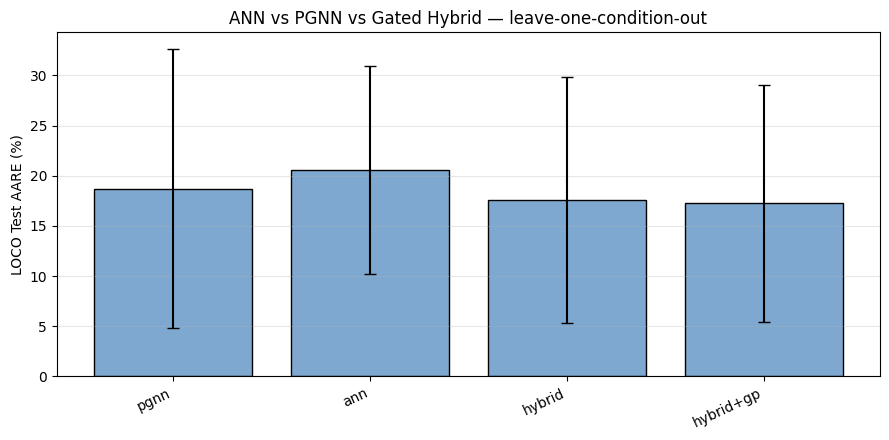

In [13]:
BASELINE = "pgnn"
agg = (all_rows.groupby("config")[["r2","rmse","aare"]].agg(["mean","std"]).round(4))
order = [c[0] for c in CONFIGS]
agg = agg.reindex(order)
print("LOCO extrapolation (ALL 21 conditions held out) — mean +/- std over seeds x folds")
print(agg)

# split view: hot vs DSA folds — the hybrid's value should concentrate in DSA
is_dsa = all_rows["fold"].str.startswith("RT") | all_rows["fold"].str.startswith("150")
for label, sub in [("HOT folds (T>=250C)", all_rows[~is_dsa]), ("DSA folds (RT+150C)", all_rows[is_dsa])]:
    print(f"\n{label}:")
    print(sub.groupby("config")[["r2","aare"]].mean().round(3).reindex(order))

base = all_rows[all_rows.config==BASELINE].set_index(["seed","fold"])["aare"]
print(f"\nPaired Δ AARE vs {BASELINE}  (+ve = improvement):")
for cfg in CONFIGS:
    name = cfg[0]
    if name == BASELINE: continue
    cur = all_rows[all_rows.config==name].set_index(["seed","fold"])["aare"]
    d = (base - cur).dropna()
    if len(d) >= 2:
        try: p = float(_stats.ttest_rel(base.loc[d.index], cur.loc[d.index]).pvalue)
        except Exception: p = float("nan")
        ci = 1.96*d.std()/max(len(d)**0.5,1)
        verdict = "helps" if (d.mean()-ci)>0 else ("hurts" if (d.mean()+ci)<0 else "within noise")
        print(f"  {name:<12} Δ={d.mean():+.2f} ± {d.std():.2f} pp  "
              f"(95%CI ±{ci:.2f}; +ve {int((d>0).sum())}/{len(d)}; p={p:.3f}) -> {verdict}")

fig, ax = plt.subplots(figsize=(9,4.5))
mu = agg[("aare","mean")].values; sd = agg[("aare","std")].values
ax.bar(range(len(order)), mu, yerr=sd, capsize=4, color="#7fa8d0", edgecolor="black")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=25, ha="right")
ax.set_ylabel("LOCO Test AARE (%)"); ax.set_title("ANN vs PGNN vs Gated Hybrid — leave-one-condition-out")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/fig_stepC_loco_hybrid.png", dpi=200, bbox_inches="tight"); plt.show()


## 12b · Harder test — Leave-One-TEMPERATURE-Out (LOTO), all configs

Holds out an entire temperature (incl. RT and 150 C). The hybrid must beat pure PGNN when the held-out T is in the DSA regime, and match it in the hot regime.


In [14]:
ALL_TEMPS = sorted({25 if c.startswith("RT") else int(c.split('-')[0]) for c in ALL_CONDS})
LOTO_TEMPS = [25, 150] + [t for t in ALL_TEMPS if t >= 250]   # hold out every temperature incl. RT/150
print("LOTO held-out temperatures:", LOTO_TEMPS)

def run_config_loto(name, kind, active, weighting, feat):
    rows=[]
    for seed in SEEDS:
        for Tc in LOTO_TEMPS:
            tr,va,te = loto_split(Tc, seed)
            F = prep_fold(tr,va,te, feature_mode=feat)
            model,_ = train_model(F, active=active, weighting=weighting,
                                  lambdas={"gate": CFG.lambda_gate}, seed=seed,
                                  run_name=f"{name}/T{Tc}/s{seed}", model_kind=kind)
            m = eval_on(model, F, te)
            rows.append({"config":name,"seed":seed,"holdout_T":Tc,**m})
    return pd.DataFrame(rows)

t0=time.time()
loto_rows = pd.concat([run_config_loto(*c) for c in CONFIGS], ignore_index=True)
loto_rows.to_csv(f"{CFG.output_dir}/stepC_loto_hybrid_raw.csv", index=False)
print(f"LOTO done in {time.time()-t0:.0f}s | rows={len(loto_rows)}")

order = [c[0] for c in CONFIGS]
agg = loto_rows.groupby("config")[["r2","rmse","aare"]].agg(["mean","std"]).round(4)
print("\nLOTO — mean +/- std over seeds x temps"); print(agg.reindex(order))
base = loto_rows[loto_rows.config=="pgnn"].set_index(["seed","holdout_T"])["aare"]
for cfg in CONFIGS:
    name = cfg[0]
    if name == "pgnn": continue
    cur = loto_rows[loto_rows.config==name].set_index(["seed","holdout_T"])["aare"]
    dd = (base-cur).dropna()
    if len(dd) < 2: continue
    try: p=float(_stats.ttest_rel(base.loc[dd.index],cur.loc[dd.index]).pvalue)
    except Exception: p=float("nan")
    ci=1.96*dd.std()/max(len(dd)**0.5,1)
    print(f"LOTO paired Δ AARE ({name} vs pgnn): {dd.mean():+.2f} ± {dd.std():.2f} pp "
          f"(95%CI ±{ci:.2f}; +ve {int((dd>0).sum())}/{len(dd)}; p={p:.3f})")


LOTO held-out temperatures: [25, 150, 250, 300, 350, 400, 450]
LOTO done in 9135s | rows=224

LOTO — mean +/- std over seeds x temps
               r2             rmse              aare         
             mean     std     mean      std     mean      std
config                                                       
pgnn      -0.4730  2.4147  41.4416  52.6589  32.0857  38.7383
ann       -0.7168  2.7639  43.7172  53.5633  32.8409  26.3591
hybrid    -0.3588  2.1713  39.8769  49.4679  29.2576  32.3319
hybrid+gp -0.3321  2.1259  39.4077  48.7508  28.0571  30.2368
LOTO paired Δ AARE (ann vs pgnn): -0.76 ± 16.63 pp (95%CI ±4.36; +ve 14/56; p=0.735)
LOTO paired Δ AARE (hybrid vs pgnn): +2.83 ± 8.41 pp (95%CI ±2.20; +ve 33/56; p=0.015)
LOTO paired Δ AARE (hybrid+gp vs pgnn): +4.03 ± 10.33 pp (95%CI ±2.71; +ve 29/56; p=0.005)


## 12c · Interpolation anchor + per-21-condition table (deployable model)

Random split = interpolation reference for all configs, plus the per-condition table. Key rows: RT-0_1 / RT-0_001 / 150-* — the hybrid's reason to exist.


In [15]:
# Interpolation anchor + per-21-condition table for ALL configs
rs_rows=[]; per_metrics=[]
for seed in SEEDS:
    tr,va,te = random_split(seed)
    for name,kind,active,weighting,feat in CONFIGS:
        F = prep_fold(tr,va,te, feature_mode=feat)
        model,_ = train_model(F, active=active, weighting=weighting,
                              lambdas={"gate": CFG.lambda_gate}, seed=seed,
                              run_name=f"rand/{name}/s{seed}", model_kind=kind)
        m=eval_on(model,F,te); rs_rows.append({"config":name,"seed":seed,**m})
        for c in ALL_CONDS:
            sel = te[cond_arr[te]==c]
            if len(sel) < 3: continue
            ypc,_ = predict(model, F, sel)
            per_metrics.append({"cond":c,"config":name,"seed":seed,**metrics(y_all[sel], ypc)})

rs = pd.DataFrame(rs_rows); rs.to_csv(f"{CFG.output_dir}/stepC_random_hybrid_raw.csv", index=False)
pm = pd.DataFrame(per_metrics); pm.to_csv(f"{CFG.output_dir}/stepC_percondition_hybrid_raw.csv", index=False)

order = [c[0] for c in CONFIGS]
print("RANDOM-split (interpolation) — mean over seeds:")
print(rs.groupby("config")[["r2","rmse","aare"]].mean().round(4).reindex(order))

tab = (pm.groupby(["cond","config"])["aare"].mean().reset_index()
         .pivot(index="cond", columns="config")["aare"])
tab = tab[[c for c in order if c in tab.columns]]
tab["T_C"] = [25 if f.startswith("RT") else int(f.split('-')[0]) for f in tab.index]
tab = tab.sort_values("T_C").drop(columns="T_C").round(2)
pd.set_option("display.width",160)
print("\nPER-CONDITION test AARE (%) — mean over seeds (watch RT/150 rows: hybrid should beat pgnn there):")
print(tab.to_string())


RANDOM-split (interpolation) — mean over seeds:
               r2    rmse     aare
config                            
pgnn       0.9681  9.7305   7.1504
ann        0.9682  9.7614  11.2040
hybrid     0.9687  9.6003   7.4110
hybrid+gp  0.9665  9.9780   7.3540

PER-CONDITION test AARE (%) — mean over seeds (watch RT/150 rows: hybrid should beat pgnn there):
config      pgnn    ann  hybrid  hybrid+gp
cond                                      
RT-0_001   15.31  13.22   15.08      14.19
RT-0_1     29.50  20.78   30.64      27.86
RT-0_01     3.61   3.85    2.52       3.17
150-0_001  14.93  18.63   18.79      15.88
150-0_1    10.21   8.53    6.32       7.17
150-0_01    7.30   8.09    7.10       7.52
250-0_01    2.47   3.07    2.31       3.32
250-0_001   8.56  12.17   10.49      10.13
250-0_1     8.55  10.97    7.63      11.05
300-0_1     3.39   4.85    3.20       3.87
300-0_001   4.38   7.26    4.56       3.91
300-0_01    4.74   4.18    4.54       5.28
350-0_01    2.94   4.96    4.23       4.3

## 12d · Gate map — where does the model trust physics?

Headline figure: the learned gate g over (T, strain rate). Expectation: g -> 1 in the hot Arrhenius regime, g -> 0 at RT/150 C (DSA). If it does, the model has *recovered the validity boundary of the constitutive law from data* — that is the paper's strongest claim.


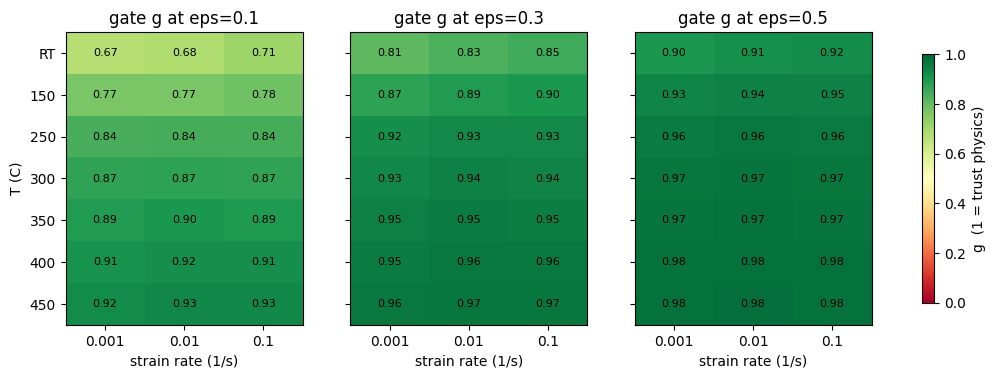

Mean gate per condition (expect low at RT/150, high at 250-450):
cond
RT-0_001     0.706
RT-0_01      0.726
RT-0_1       0.764
150-0_001    0.776
150-0_01     0.783
150-0_1      0.809
250-0_001    0.877
250-0_01     0.883
250-0_1      0.897
300-0_001    0.907
300-0_01     0.913
300-0_1      0.921
350-0_001    0.929
350-0_01     0.939
400-0_001    0.942
350-0_1      0.946
400-0_01     0.951
400-0_1      0.953
450-0_001    0.954
450-0_1      0.960
450-0_01     0.961


In [16]:
seed_everything(CFG.seed)
tr,va,te = random_split(CFG.seed)
Fg = prep_fold(tr,va,te)
mg,_ = train_model(Fg, active=("gate",), weighting="fixed", lambdas={"gate": CFG.lambda_gate},
                   seed=CFG.seed, run_name="gatemap", model_kind="hybrid")

temps_C = [25,150,250,300,350,400,450]
srs = [0.001,0.01,0.1]
eps_levels = [0.10,0.30,0.50]
fig, axes = plt.subplots(1, len(eps_levels), figsize=(13,3.8), sharey=True)
for ax, e0 in zip(np.atleast_1d(axes), eps_levels):
    G = np.zeros((len(temps_C), len(srs)))
    for i, Tc in enumerate(temps_C):
        for j, s0 in enumerate(srs):
            raw = _featurize(np.array([Tc+273.15],dtype=np.float32),
                             np.log(np.array([s0],dtype=np.float32)),
                             np.array([e0],dtype=np.float32), Fg.feature_mode, Fg.Q0)
            xs = torch.tensor(Fg.sx.transform(raw).astype(np.float32), device=Fg.device)
            with torch.no_grad():
                G[i,j] = float(mg.gate_value(xs))
    im = ax.imshow(G, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(srs))); ax.set_xticklabels([str(s) for s in srs])
    ax.set_yticks(range(len(temps_C))); ax.set_yticklabels(["RT" if t==25 else t for t in temps_C])
    ax.set_title(f"gate g at eps={e0}"); ax.set_xlabel("strain rate (1/s)")
    for i in range(G.shape[0]):
        for j in range(G.shape[1]):
            ax.text(j, i, f"{G[i,j]:.2f}", ha="center", va="center", fontsize=8)
np.atleast_1d(axes)[0].set_ylabel("T (C)")
fig.colorbar(im, ax=np.atleast_1d(axes).tolist(), shrink=0.85, label="g  (1 = trust physics)")
plt.savefig(f"{CFG.output_dir}/fig_stepC_gate_map.png", dpi=200, bbox_inches="tight"); plt.show()

# mean gate per condition on the actual data points
xg = torch.tensor(Fg.sx.transform(Fg.X).astype(np.float32), device=Fg.device)
with torch.no_grad():
    gall = mg.gate_value(xg).cpu().numpy().flatten()
gdf = pd.DataFrame({"cond": cond_arr, "g": gall}).groupby("cond")["g"].mean().round(3)
print("Mean gate per condition (expect low at RT/150, high at 250-450):")
print(gdf.sort_values().to_string())


## 14 · SCAM Parameter Validation (learned vs classical, inside valid window)

In [17]:
# Train one full-data PGNN and compare learned Arrhenius params to SCAM where SCAM is valid.
tr, va, te = random_split(CFG.seed)
Fv = prep_fold(tr, va, te)
m_val, _ = train_model(Fv, seed=CFG.seed, run_name="PGNN/full", model_kind="pgnn")
idx_valid = np.where(SCAM_VALID)[0]
_, lp = predict(m_val, Fv, idx_valid)
ev = eps_raw[idx_valid]
print(f"Validation on {len(idx_valid)} SCAM-valid points (T>=250C, eps in [{CFG.scam_eps_min},{CFG.scam_eps_max}])")
print(f"{'param':<6}{'learned mean±std':>22}{'SCAM mean±std':>22}")
for k, div, unit in [("alpha",1,"1/MPa"),("n",1,""),("Q",1e3,"kJ/mol"),("lnA",1,"")]:
    lv = lp[k].flatten()/div
    sv = np.polyval(SCAM_POLY_COEFFS[k], ev)/div
    print(f"{k:<6}{lv.mean():>10.3f}±{lv.std():<8.3f}{sv.mean():>12.3f}±{sv.std():<8.3f} {unit}")
print("\nLiterature anchor: Q for Al hot working ~150-185 kJ/mol (self-diffusion ~142 kJ/mol).")

Validation on 435 SCAM-valid points (T>=250C, eps in [0.05,0.19])
param       learned mean±std         SCAM mean±std
alpha      0.025±0.001          0.019±0.000    1/MPa
n          5.768±0.110          5.633±0.460    
Q        179.790±1.736        157.431±3.416    kJ/mol
lnA       26.897±0.189         25.009±0.839    

Literature anchor: Q for Al hot working ~150-185 kJ/mol (self-diffusion ~142 kJ/mol).


## 15 · How to run

1. Upload `al6011_downsampled_full.xlsx` as a Kaggle dataset; `_find_data_path` auto-finds it under `/kaggle/input`.
2. Smoke test first: `CFG.quick = True` (60 epochs, 2 folds) — confirm every cell runs.
3. Full study: `CFG.quick = False`. Cost = configs(4) x seeds(8) x folds(21) trainings for LOCO — stage it: run with `SEEDS = CFG.seeds[:3]` first; if the hybrid signal is real, extend to all 8 seeds.
4. Key outputs: `stepC_loco_hybrid_raw.csv`, `stepC_loto_hybrid_raw.csv`, `stepC_percondition_hybrid_raw.csv`, `fig_stepC_gate_map.png`.
5. Success criteria (decided BEFORE looking at results, to stay honest):
   - **Hybrid vs PGNN on DSA folds (RT/150):** this is the hypothesis — the free branch + gate should cut RT-0_1 (~30% AARE) substantially.
   - **Hybrid vs PGNN on HOT folds:** should be ~equal or slightly better (gate prior keeps physics in charge). If hybrid is much worse here, the gate is leaking capacity — raise `lambda_gate`.
   - **ANN vs Hybrid:** hybrid should beat ANN under LOCO/LOTO (physics helps extrapolation) — this is the 3-way story.
   - **Gate map:** g high at 250-450 C, low at RT/150. If the map recovers this boundary, that figure carries the paper.
6. Optional: uncomment the `lnZ` configs to test the representation hypothesis (Q0 is re-fitted per fold on train only; measured global value = 156.8 kJ/mol).
